# Task 3: Neural Surrogate, Architecture 2 of 4 (Residual MLP)

Second of four feed-forward architectures compared in Task 3. The Residual MLP
adds skip connections to the Deep MLP block pattern; otherwise it reuses the
exact same shared pipeline (data loading, `log(x_H2_4)`-aware scaling,
stratified train/val split, training loop, metrics, parity plots) from
`nn_utils.py`.

Architecture (RTDL-style, pre-norm with bottleneck): input projection, then N
residual blocks (`LayerNorm, Linear(d, d*2), GELU, Dropout1, Linear(d*2, d),
Dropout2, then add x`), then a final LayerNorm, then a linear head to 15 outputs. Follows
Gorishniy et al., Revisiting Deep Learning Models for Tabular Data
(NeurIPS 2021).

The previous design was post-norm (`Linear, GELU, Drop, Linear, add x, LayerNorm,
GELU`). It reached test R²=0.98742 but regressed on `x_MeOH_4` and stopped
early at epoch 44; the old block is kept commented inside section 4 in case we need
to revert. See section 4 for the upgrade rationale.

Sweep: two iterations of a 32-config full grid over (lr, wd, dropout,
hidden) and n_blocks. Iteration 2 pushes heavier regularization and smaller
hidden widths based on iteration-1 marginals.

Conventions (same as `EDA&ElasticNet.ipynb`, `XGBoost.ipynb`, `NN_DeepMLP.ipynb`):
- 9 inputs, 15 modeled outputs; 4 deterministic outputs (`T3`, `P3`, `P4`, `MeOH_purity_stream4`) recovered by direct assignment.
- `x_H2_4` trained in log-space; the other 14 outputs are standardized only.
- 80/20 train/val split stratified on `n4_total == 0`, `random_state=42`.
- Test set (`dataset/test.csv`) untouched until the final evaluation cells.

Result: the iter-2 winner `lr1e-03_wd1e-03_d0.20_h32_b4` (17,903
params) reaches test R²=0.99213, which clears both XGBoost (0.987) and the previous
post-norm run (0.98742). `x_MeOH_4` R²=0.968 (target >0.95 met); the weakest
output `x_H2_4` is R²=0.958 (vs XGBoost 0.890).

## 0. Install PyTorch (run once)

In [1]:
import subprocess, sys
for pkg in ["torch"]:
    try:
        __import__(pkg)
        print(f"{pkg} already installed")
    except ImportError:
        print(f"Installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        print("\n*** Restart the kernel before running the remaining cells. ***")

torch already installed


## 1. Imports and reproducibility

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

import nn_utils as nu
from nn_utils import (
    INPUT_COLS, OUTPUT_COLS, MODEL_OUTPUT_COLS, RANDOM_STATE,
    load_data, build_scaled_split, make_dataloaders,
    TrainConfig, train_model, predict_raw,
    regression_metrics_by_output, regime_diagnostics,
    assemble_full_prediction, parity_grid, save_checkpoint,
)

nu.seed_everything(RANDOM_STATE)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} | device: {device}")

torch 2.5.1+cu121 | device: cuda


## 2. Load data

Same loading convention as `XGBoost.ipynb` and `NN_DeepMLP.ipynb`: 9 inputs, 19 raw outputs (we model 15).

In [3]:
data = load_data("dataset")
print(f"Train : {len(data.X_train):>5} rows | {len(INPUT_COLS)} inputs | {len(OUTPUT_COLS)} outputs")
print(f"Test  : {len(data.X_test):>5} rows")
print(f"No-liquid rows — train: {data.no_liquid_train.sum()} | test: {data.no_liquid_test.sum()}")
print(f"\nModeled outputs ({len(MODEL_OUTPUT_COLS)}): {MODEL_OUTPUT_COLS}")

Train :  8000 rows | 9 inputs | 19 outputs
Test  :  2000 rows
No-liquid rows — train: 13 | test: 4

Modeled outputs (15): ['Q1_MW', 'Q2_MW', 'T_reactor_out', 'X_CO', 'n3_total', 'y_CO_3', 'y_H2_3', 'y_MeOH_3', 'y_H2O_3', 'n4_total', 'x_CO_4', 'x_H2_4', 'x_MeOH_4', 'x_H2O_4', 'MeOH_recovery']


## 3. Train/val split and scaling pipeline

Carve an 80/20 train/val split out of `train.csv`, stratified on the no-liquid
indicator. Fit `StandardScaler` on the training portion only. Targets pass
through `log` on `x_H2_4` first, then `StandardScaler` on the resulting
15-column matrix. See `nn_utils.TargetTransformer` for the exact transform.

In [4]:
scaled = build_scaled_split(data, val_size=0.2, seed=RANDOM_STATE)

print(f"Train fit : {len(scaled.train_idx):>5} rows | no-liquid: {scaled.no_liquid_train_fit.sum()}")
print(f"Val       : {len(scaled.val_idx):>5} rows | no-liquid: {scaled.no_liquid_val.sum()}")

Train fit :  6400 rows | no-liquid: 10
Val       :  1600 rows | no-liquid: 3


## 4. Residual MLP architecture (RTDL-style pre-norm, bottleneck)

Block pattern (Gorishniy et al., Revisiting Deep Learning Models for Tabular
Data, NeurIPS 2021):

```
x -> LayerNorm -> Linear(d, d*mult) -> GELU -> Dropout1 -> Linear(d*mult, d) -> Dropout2 -> add x
```

Differences vs the previous block (`Linear, GELU, Drop, Linear, add x, LayerNorm, GELU`):

1. Pre-norm, not post-norm: gradient flows through the residual as an
   identity, which is empirically more stable (Xiong et al. 2020).
2. Bottleneck expansion with `hidden_mult = 2.0`: each block lifts
   `d` to `2d` and back to `d`, giving real non-linear capacity per block. Two `d` to `d`
   linears (the old design) waste parameters because the activation between
   them adds little extra after a linear projection at the same width.
3. Two dropouts (main and output, the latter at half rate) instead of one.
4. No activation or norm after the residual add: this keeps the residual
   stream a clean identity path. A final `LayerNorm(hidden)` before the
   head is standard in pre-norm stacks.

`hidden_mult` is fixed at 2.0 (the RTDL default); `hidden`, `n_blocks`, and
`dropout` remain sweep-tunable.

Previous (post-norm) architecture, kept for revert. The earlier version
of this notebook used `x -> Linear -> GELU -> Drop -> Linear -> add x -> LayerNorm -> GELU`
(post-norm with an activation after the residual add). It reached test
R²=0.98742, but `x_MeOH_4` regressed to R²=0.936 and the winner stopped at
epoch 44. The exact old code is preserved as a commented block at the top of
the cell below so it can be uncommented to revert.

In [5]:
# ---------------------------------------------------------------------------
# PREVIOUS ARCHITECTURE: post-norm residual block (kept commented for revert).
# Result: test R²=0.98742 at winner lr1e-03_wd1e-05_d0.10_h64_b4
# (35,407 params, best val loss 0.04615 @ epoch 44, 104 epochs total).
# Weakness: x_MeOH_4 R²=0.936 (regression vs Deep MLP's 0.962).
# To revert: comment out the new RTDL-style classes below and un-comment this.
# ---------------------------------------------------------------------------
# class ResidualBlock(nn.Module):
#     def __init__(self, hidden: int, dropout: float):
#         super().__init__()
#         self.lin1 = nn.Linear(hidden, hidden)
#         self.lin2 = nn.Linear(hidden, hidden)
#         self.norm = nn.LayerNorm(hidden)
#         self.act  = nn.GELU()
#         self.drop = nn.Dropout(dropout)
#
#     def forward(self, x):
#         r = x
#         x = self.act(self.lin1(x))
#         x = self.drop(x)
#         x = self.lin2(x)
#         x = self.norm(x + r)
#         return self.act(x)
#
#
# class ResidualMLP(nn.Module):
#     def __init__(
#         self,
#         in_dim: int = len(INPUT_COLS),
#         out_dim: int = len(MODEL_OUTPUT_COLS),
#         hidden: int = 64,
#         n_blocks: int = 4,
#         dropout: float = 0.20,
#     ):
#         super().__init__()
#         self.input_proj = nn.Linear(in_dim, hidden)
#         self.blocks = nn.ModuleList(
#             [ResidualBlock(hidden, dropout) for _ in range(n_blocks)]
#         )
#         self.head = nn.Linear(hidden, out_dim)
#
#     def forward(self, x):
#         x = self.input_proj(x)
#         for blk in self.blocks:
#             x = blk(x)
#         return self.head(x)
# ---------------------------------------------------------------------------


# === NEW ARCHITECTURE: RTDL-style pre-norm residual block with bottleneck ===
# Reference: Gorishniy et al., "Revisiting Deep Learning Models for Tabular
# Data" (NeurIPS 2021). Block: LayerNorm, Linear(d to d*mult), GELU, Drop1,
# Linear(d*mult to d), Drop2, then add x. No activation or norm after the residual add,
# so the residual stream stays a clean identity path.

class ResidualBlock(nn.Module):
    """RTDL-style pre-norm residual block with bottleneck expansion.

    forward:  x -> LayerNorm -> Linear(d to d*mult) -> GELU -> Dropout1
                -> Linear(d*mult to d) -> Dropout2 -> add x
    """

    def __init__(self, hidden: int, dropout: float, hidden_mult: float = 2.0):
        super().__init__()
        d_hidden = int(hidden * hidden_mult)
        self.norm  = nn.LayerNorm(hidden)
        self.lin1  = nn.Linear(hidden, d_hidden)
        self.act   = nn.GELU()
        self.drop1 = nn.Dropout(dropout)
        self.lin2  = nn.Linear(d_hidden, hidden)
        self.drop2 = nn.Dropout(dropout * 0.5)

    def forward(self, x):
        r = x
        x = self.norm(x)
        x = self.lin1(x)
        x = self.act(x)
        x = self.drop1(x)
        x = self.lin2(x)
        x = self.drop2(x)
        return x + r


class ResidualMLP(nn.Module):
    def __init__(
        self,
        in_dim: int = len(INPUT_COLS),
        out_dim: int = len(MODEL_OUTPUT_COLS),
        hidden: int = 64,
        n_blocks: int = 4,
        dropout: float = 0.20,
        hidden_mult: float = 2.0,
    ):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, hidden)
        self.blocks = nn.ModuleList(
            [ResidualBlock(hidden, dropout, hidden_mult) for _ in range(n_blocks)]
        )
        self.final_norm = nn.LayerNorm(hidden)
        self.head = nn.Linear(hidden, out_dim)

    def forward(self, x):
        x = self.input_proj(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.final_norm(x)
        return self.head(x)


# Sanity check: instantiate at the inherited Deep MLP winner config.
_baseline = ResidualMLP(hidden=64, n_blocks=4, dropout=0.20)
print(_baseline)
print(f"\nTrainable parameters (hidden=64, n_blocks=4, mult=2.0): "
      f"{sum(p.numel() for p in _baseline.parameters() if p.requires_grad):,}")

ResidualMLP(
  (input_proj): Linear(in_features=9, out_features=64, bias=True)
  (blocks): ModuleList(
    (0-3): 4 x ResidualBlock(
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (lin1): Linear(in_features=64, out_features=128, bias=True)
      (act): GELU(approximate='none')
      (drop1): Dropout(p=0.2, inplace=False)
      (lin2): Linear(in_features=128, out_features=64, bias=True)
      (drop2): Dropout(p=0.1, inplace=False)
    )
  )
  (final_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=64, out_features=15, bias=True)
)

Trainable parameters (hidden=64, n_blocks=4, mult=2.0): 68,559


## 5. Hyperparameter sweep (iteration 2, heavier reg, smaller width)

Small full grid over (lr, wd, dropout, hidden) and n_blocks, still 32 configs total.
All other hyperparameters are fixed: ES patience=60, max_epochs=1000, batch=128,
`ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-8)`, grad_clip=1.0, seed=42.

| Axis      | Iteration 1   | Iteration 2 |
|-----------|---------------|-----------------|
| `lr`      | {1e-3, 3e-4}  | {1e-3, 3e-4}    |
| `wd`      | {1e-5, 5e-4}  | {5e-4, 1e-3} |
| `dropout` | {0.10, 0.20}  | {0.20, 0.30} |
| `hidden`  | {64, 128}     | {16, 32}    |
| `n_blocks`| {2, 4}        | {2, 4}          |

Why iteration 2: the iteration-1 winner was `lr1e-03_wd5e-04_d0.20_h64_b4`
(best val loss 0.03092 at epoch 36, test R²=0.98997, clears XGBoost
0.987). Iteration-1 marginals were clear: `wd=5e-4` beat `1e-5`,
`dropout=0.20` beat `0.10`, `hidden=64` beat `128`. So we push regularization
heavier and shrink hidden further (16, 32) to test whether a more compact,
better-regularized model beats the iteration-1 winner. Note: the
iter-1 winner (`h64`) is not replicated here since h=64 is outside iter-2's
grid; the worst case is that iter-2 finds no improvement.

`hidden_mult` stays at 2.0. Per-config param counts now range roughly
2.7k to 18k (was about 35k to 268k in iter 1).

Training-loop hyperparameters (unchanged from iter 1):

- `lr_patience` = 5 (halve LR after fewer plateau epochs)
- `lr_min` = 1e-8 (deeper floor so LR reductions don't hit the cap)
- `early_stopping_patience` = 60 (give slower configs more time before ES fires)

Generated programmatically via `itertools.product`. Run this cell unattended.

In [6]:
from itertools import product

# Sweep iteration 2: heavier regularization, smaller width.
# Previous grid (iteration 1): lr{1e-3,3e-4} x wd{1e-5,5e-4} x dropout{0.10,0.20}
#                              x hidden{64,128} x n_blocks{2,4}.
# Iteration 1 winner on the new RTDL block: lr1e-03_wd5e-04_d0.20_h64_b4,
# best val 0.03092 @ epoch 36, test R²=0.98997 (clears XGBoost 0.987).
# Marginals showed wd=5e-4 > 1e-5, dropout=0.20 > 0.10, hidden=64 > 128.
# Iteration 2 drops the under-regularized end and pushes further:
sweep_configs = []
for lr, wd, dr, hid, nb in product(
    [1e-3, 3e-4],
    [5e-4, 1e-3],     # was {1e-5, 5e-4}, drop lightest, add heaviest
    [0.20, 0.30],     # was {0.10, 0.20}, drop lightest, add heaviest
    [32, 16],         # was {64, 128}, h=128 lost iter 1; try h=32
    [2, 4],
):
    sweep_configs.append({
        "name":       f"lr{lr:.0e}_wd{wd:.0e}_d{dr:.2f}_h{hid}_b{nb}",
        "lr":         lr,
        "wd":         wd,
        "dropout":    dr,
        "hidden":     hid,
        "n_blocks":   nb,
        "es_p":       60,
        "max_epochs": 1000,
    })

print(f"Total sweep configs: {len(sweep_configs)}")

sweep_models    = {}
sweep_histories = {}
sweep_results   = []

for i, cfg in enumerate(sweep_configs, 1):
    print(f"\n=== [{i}/{len(sweep_configs)}] {cfg['name']} ===")
    nu.seed_everything(RANDOM_STATE)
    candidate = ResidualMLP(
        hidden=cfg["hidden"], n_blocks=cfg["n_blocks"], dropout=cfg["dropout"]
    )
    n_params = sum(p.numel() for p in candidate.parameters() if p.requires_grad)
    train_loader, val_loader = make_dataloaders(scaled, batch_size=128, seed=RANDOM_STATE)
    cand_config = TrainConfig(
        max_epochs=cfg["max_epochs"],
        lr=cfg["lr"],
        weight_decay=cfg["wd"],
        lr_factor=0.5,
        lr_patience=5,
        lr_min=1e-8,
        early_stopping_patience=cfg["es_p"],
        grad_clip_norm=1.0,
        device=device,
        log_every=200,
    )
    hist = train_model(candidate, train_loader, val_loader, config=cand_config)

    # Cheap test-R² readout (tie-breaker / sanity check).
    pred_mod = predict_raw(candidate, scaled.X_test_s, scaled.Y_transformer, device=device)
    pred_full = assemble_full_prediction(pred_mod, data.X_test)
    m = regression_metrics_by_output(data.y_test, pred_full, OUTPUT_COLS)
    test_r2 = m["R2"].mean(skipna=True)

    sweep_models[cfg["name"]]    = candidate
    sweep_histories[cfg["name"]] = hist
    sweep_results.append({
        "name":          cfg["name"],
        "lr":            cfg["lr"],
        "wd":            cfg["wd"],
        "dropout":       cfg["dropout"],
        "hidden":        cfg["hidden"],
        "n_blocks":      cfg["n_blocks"],
        "params":        n_params,
        "best_val_loss": hist.best_val_loss,
        "best_epoch":    hist.best_epoch,
        "epochs_run":    len(hist.val_loss),
        "test_R2":       test_r2,
    })
    print(f"  → best val {hist.best_val_loss:.5f} @ epoch {hist.best_epoch} | "
          f"test R²={test_r2:.5f} | params={n_params:,}")

sweep_df = pd.DataFrame(sweep_results).sort_values("best_val_loss").reset_index(drop=True)
print("\nTop 10 sweep configs (sorted by best val loss):")
print(sweep_df.head(10).round(5).to_string(index=False))

Total sweep configs: 32

=== [1/32] lr1e-03_wd5e-04_d0.20_h32_b2 ===
  epoch   1 | train 0.58681 | val 0.24319 | lr 1.00e-03 | best@1
  epoch   2 | train 0.20554 | val 0.15179 | lr 1.00e-03 | best@2
  epoch   3 | train 0.15622 | val 0.12914 | lr 1.00e-03 | best@3
  epoch   4 | train 0.13553 | val 0.11514 | lr 1.00e-03 | best@4
  epoch   5 | train 0.12150 | val 0.10407 | lr 1.00e-03 | best@5
  epoch   6 | train 0.10932 | val 0.09577 | lr 1.00e-03 | best@6
  epoch   7 | train 0.10077 | val 0.09078 | lr 1.00e-03 | best@7
  epoch   8 | train 0.09453 | val 0.08680 | lr 1.00e-03 | best@8
  epoch   9 | train 0.08968 | val 0.08377 | lr 1.00e-03 | best@9
  epoch  10 | train 0.08623 | val 0.08220 | lr 1.00e-03 | best@10
  epoch  11 | train 0.08286 | val 0.07997 | lr 1.00e-03 | best@11
  epoch  12 | train 0.07977 | val 0.07803 | lr 1.00e-03 | best@12
  epoch  13 | train 0.07752 | val 0.07627 | lr 1.00e-03 | best@13
  epoch  14 | train 0.07548 | val 0.07498 | lr 1.00e-03 | best@14
  epoch  15 | tr

## 5b. Marginal effect of each hyperparameter

For each sweep axis, average the best val loss across all other axes. This
reveals which hyperparameter actually mattered (smaller average loss = better).

In [7]:
for axis in ["lr", "wd", "dropout", "hidden", "n_blocks"]:
    marg = sweep_df.groupby(axis)["best_val_loss"].agg(["mean", "min", "count"]).round(5)
    print(f"\n--- by {axis} ---")
    print(marg.to_string())


--- by lr ---
           mean      min  count
lr                             
0.0003  0.04405  0.04254     16
0.0010  0.03760  0.02715     16

--- by wd ---
           mean      min  count
wd                             
0.0005  0.04091  0.02982     16
0.0010  0.04073  0.02715     16

--- by dropout ---
            mean      min  count
dropout                         
0.2      0.04016  0.02715     16
0.3      0.04149  0.03446     16

--- by hidden ---
           mean      min  count
hidden                         
16      0.04149  0.03615     16
32      0.04016  0.02715     16

--- by n_blocks ---
             mean      min  count
n_blocks                         
2         0.04248  0.03741     16
4         0.03916  0.02715     16


## 6. Sweep diagnostics: loss curves of top 8 configs

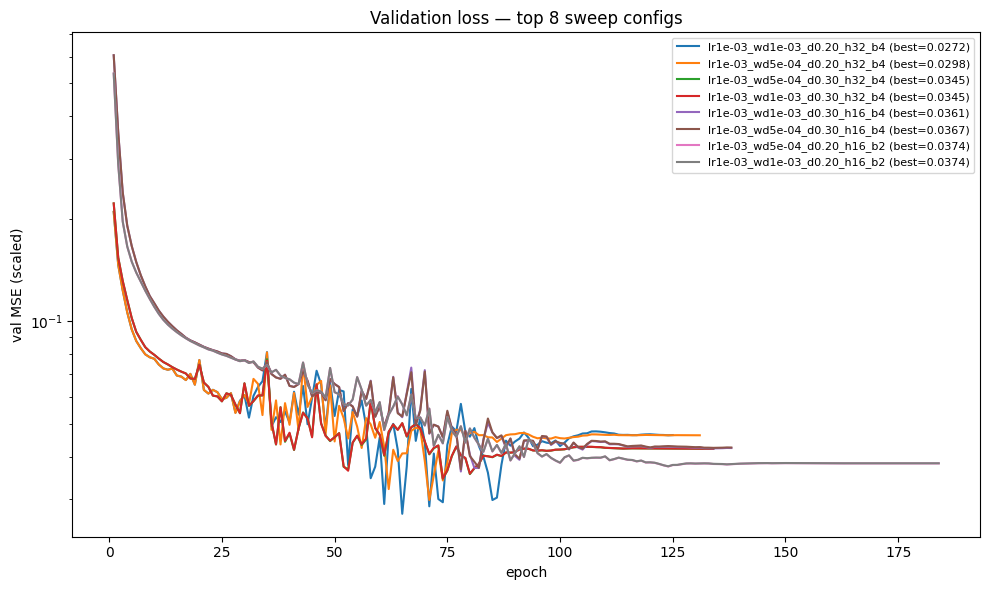

In [8]:
# Plot the val-loss curves of the top 8 configs only; 32 lines would be unreadable.
top_configs = sweep_df.head(8)["name"].tolist()

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for name in top_configs:
    hist = sweep_histories[name]
    epochs = np.arange(1, len(hist.val_loss) + 1)
    ax.plot(epochs, hist.val_loss, label=f"{name} (best={hist.best_val_loss:.4f})")
ax.set_xlabel("epoch"); ax.set_ylabel("val MSE (scaled)")
ax.set_yscale("log"); ax.set_title("Validation loss — top 8 sweep configs")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

## 7. Select winner and adopt as the final Residual MLP

The lowest val-loss configuration is taken as the final model. The rest of
the notebook (test evaluation, parity plots, checkpoint) treats it as the
final Residual MLP.

In [9]:
winner_name = sweep_df.iloc[0]["name"]
winner_cfg  = next(c for c in sweep_configs if c["name"] == winner_name)
model       = sweep_models[winner_name]
history     = sweep_histories[winner_name]

print(f"Winner: {winner_name}")
print(f"  hyperparameters: lr={winner_cfg['lr']:.0e}, wd={winner_cfg['wd']:.0e}, "
      f"dropout={winner_cfg['dropout']}, hidden={winner_cfg['hidden']}, "
      f"n_blocks={winner_cfg['n_blocks']}, ES patience={winner_cfg['es_p']}")
print(f"  best val loss : {history.best_val_loss:.5f} at epoch {history.best_epoch}")
print(f"  trained epochs: {len(history.val_loss)}")
print(f"  parameters    : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Winner: lr1e-03_wd1e-03_d0.20_h32_b4
  hyperparameters: lr=1e-03, wd=1e-03, dropout=0.2, hidden=32, n_blocks=4, ES patience=60
  best val loss : 0.02715 at epoch 65
  trained epochs: 125
  parameters    : 17,903


## 8. Final training curves (winner only)

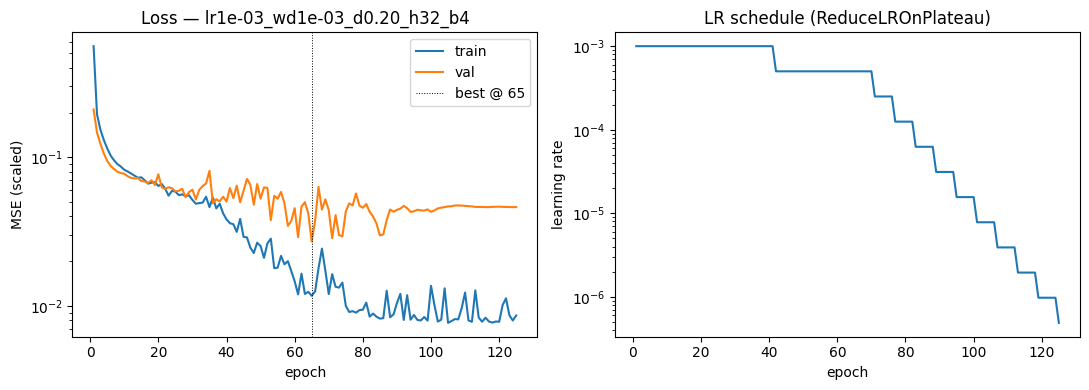

In [10]:
fig, (ax_loss, ax_lr) = plt.subplots(1, 2, figsize=(11, 4))
epochs = np.arange(1, len(history.train_loss) + 1)
ax_loss.plot(epochs, history.train_loss, label="train")
ax_loss.plot(epochs, history.val_loss, label="val")
ax_loss.axvline(history.best_epoch, color="k", lw=0.7, ls=":", label=f"best @ {history.best_epoch}")
ax_loss.set_xlabel("epoch"); ax_loss.set_ylabel("MSE (scaled)")
ax_loss.set_yscale("log"); ax_loss.set_title(f"Loss — {winner_name}"); ax_loss.legend()

ax_lr.plot(epochs, history.lr)
ax_lr.set_xlabel("epoch"); ax_lr.set_ylabel("learning rate")
ax_lr.set_yscale("log"); ax_lr.set_title("LR schedule (ReduceLROnPlateau)")
plt.tight_layout(); plt.show()

## 9. Test-set evaluation

Predict the held-out `test.csv`, invert the target transform, then recover
the 4 deterministic outputs (`T3`, `P3`, `P4`, `MeOH_purity_stream4`) so the
metric tables are directly comparable with the EN / XGBoost / Deep MLP reports.

In [11]:
test_pred_modeled = predict_raw(model, scaled.X_test_s, scaled.Y_transformer, device=device)
test_pred_full    = assemble_full_prediction(test_pred_modeled, data.X_test)

rmlp_test_per_output = regression_metrics_by_output(
    data.y_test, test_pred_full, OUTPUT_COLS
).sort_values("RMSE", ascending=False)

print("Residual MLP — test per-output metrics (sorted by RMSE, worst first):")
rmlp_test_per_output.round(5)

Residual MLP — test per-output metrics (sorted by RMSE, worst first):


,output,RMSE,MAE,R2
6,n3_total,6.38940,4.49796,0.99922
12,n4_total,1.28251,0.73842,0.99678
2,T_reactor_out,0.33020,0.23501,0.99848
15,x_MeOH_4,0.02745,0.00483,0.96842
18,MeOH_purity_stream4,0.02745,0.00483,0.96842
0,Q1_MW,0.01971,0.01433,0.99832
17,MeOH_recovery,0.01402,0.00664,0.99395
16,x_H2O_4,0.00798,0.00382,0.99726
8,y_H2_3,0.00216,0.00156,0.99884
7,y_CO_3,0.00213,0.00152,0.99887


## 10. Aggregate test metrics

In [12]:
rmlp_m = regression_metrics_by_output(data.y_test, test_pred_full, OUTPUT_COLS)
print(
    f"Residual MLP test — "
    f"RMSE: {rmlp_m['RMSE'].mean():.5f} | "
    f"MAE: {rmlp_m['MAE'].mean():.5f} | "
    f"R²: {rmlp_m['R2'].mean(skipna=True):.5f}"
)

Residual MLP test — RMSE: 0.42661 | MAE: 0.29002 | R²: 0.99213


## 11. Regime diagnostics (all / liquid / no-liquid)

In [13]:
rmlp_test_diagnostics = regime_diagnostics(
    data.y_test, test_pred_full, data.no_liquid_test, columns=OUTPUT_COLS
)
rmlp_test_diagnostics.round(5)

,group,rows,mean_RMSE,mean_MAE,mean_R2
0,all_rows,2000,0.42661,0.29002,0.99213
1,liquid_rows,1996,0.41262,0.28704,0.99501
2,no_liquid_rows,4,2.26317,1.77645,-1.78122


## 12. Comparison vs Task 2 baselines and Deep MLP

Elastic Net and XGBoost aggregates are taken from `EDA&ElasticNet.ipynb` and
`XGBoost.ipynb`. Deep MLP metrics are loaded from `models/task3/deep.pt`.

In [14]:
import torch as _torch

elastic_net_test = {"RMSE": 0.657, "MAE": 0.486, "R2": 0.938}
xgboost_test     = {"RMSE": 0.289, "MAE": 0.224, "R2": 0.987}

# Pull Deep MLP test aggregates from its checkpoint.
_deep_ckpt = _torch.load("models/task3/deep.pt", map_location="cpu", weights_only=False)
dmlp_test_agg = _deep_ckpt["extra"]["test_agg"]
dmlp_test_agg = {k: float(v) for k, v in dmlp_test_agg.items()}

rmlp_test_agg = {
    "RMSE": rmlp_m["RMSE"].mean(),
    "MAE":  rmlp_m["MAE"].mean(),
    "R2":   rmlp_m["R2"].mean(skipna=True),
}

comparison = pd.DataFrame({
    "Elastic Net (test)":  elastic_net_test,
    "XGBoost (test)":      xgboost_test,
    "Deep MLP (test)":     dmlp_test_agg,
    "Residual MLP (test)": rmlp_test_agg,
}).T
comparison["RMSE_vs_XGB"] = comparison["RMSE"] - xgboost_test["RMSE"]
comparison["R2_vs_XGB"]   = comparison["R2"]   - xgboost_test["R2"]

print("Aggregate test comparison:")
comparison.round(5)

Aggregate test comparison:


,RMSE,MAE,R2,RMSE_vs_XGB,R2_vs_XGB
Elastic Net (test),0.65700,0.48600,0.93800,0.36800,-0.04900
XGBoost (test),0.28900,0.22400,0.98700,0.00000,0.00000
Deep MLP (test),1.81498,1.36422,0.98270,1.52598,-0.00430
Residual MLP (test),0.42661,0.29002,0.99213,0.13761,0.00513


In [15]:
# Per-output R² for the outputs previously identified as weakest under EN / XGBoost / Deep MLP.
weak_outputs = ["y_H2O_3", "Q2_MW", "MeOH_recovery", "x_H2_4", "x_CO_4", "x_MeOH_4"]
en_weak  = {"y_H2O_3": 0.752, "Q2_MW": 0.836, "MeOH_recovery": 0.858}
xgb_weak = {"y_H2O_3": 0.994, "Q2_MW": 0.989, "MeOH_recovery": 0.998,
            "x_H2_4": 0.890, "x_CO_4": 0.963, "x_MeOH_4": 0.962}
dmlp_weak = {"y_H2O_3": 0.987, "Q2_MW": 0.977, "MeOH_recovery": 0.991,
             "x_H2_4": 0.942, "x_CO_4": 0.977, "x_MeOH_4": 0.962}

rmlp_weak = rmlp_test_per_output.set_index("output")["R2"].loc[weak_outputs].to_dict()

weak_comparison = pd.DataFrame({
    "Elastic Net R²":  en_weak,
    "XGBoost R²":      xgb_weak,
    "Deep MLP R²":     dmlp_weak,
    "Residual MLP R²": rmlp_weak,
}).T

print("Per-output R² on previously-weak outputs:")
weak_comparison.round(4)

Per-output R² on previously-weak outputs:


,y_H2O_3,Q2_MW,MeOH_recovery,x_H2_4,x_CO_4,x_MeOH_4
Elastic Net R²,0.7520,0.8360,0.8580,NaN,NaN,NaN
XGBoost R²,0.9940,0.9890,0.9980,0.8900,0.9630,0.9620
Deep MLP R²,0.9870,0.9770,0.9910,0.9420,0.9770,0.9620
Residual MLP R²,0.9962,0.9967,0.9939,0.9583,0.9873,0.9684


## 13. Parity plots

Full 19-output parity grid. Train predictions on validation-fold rows only
(the model hasn't seen those during training); test predictions on the entire
held-out test set.

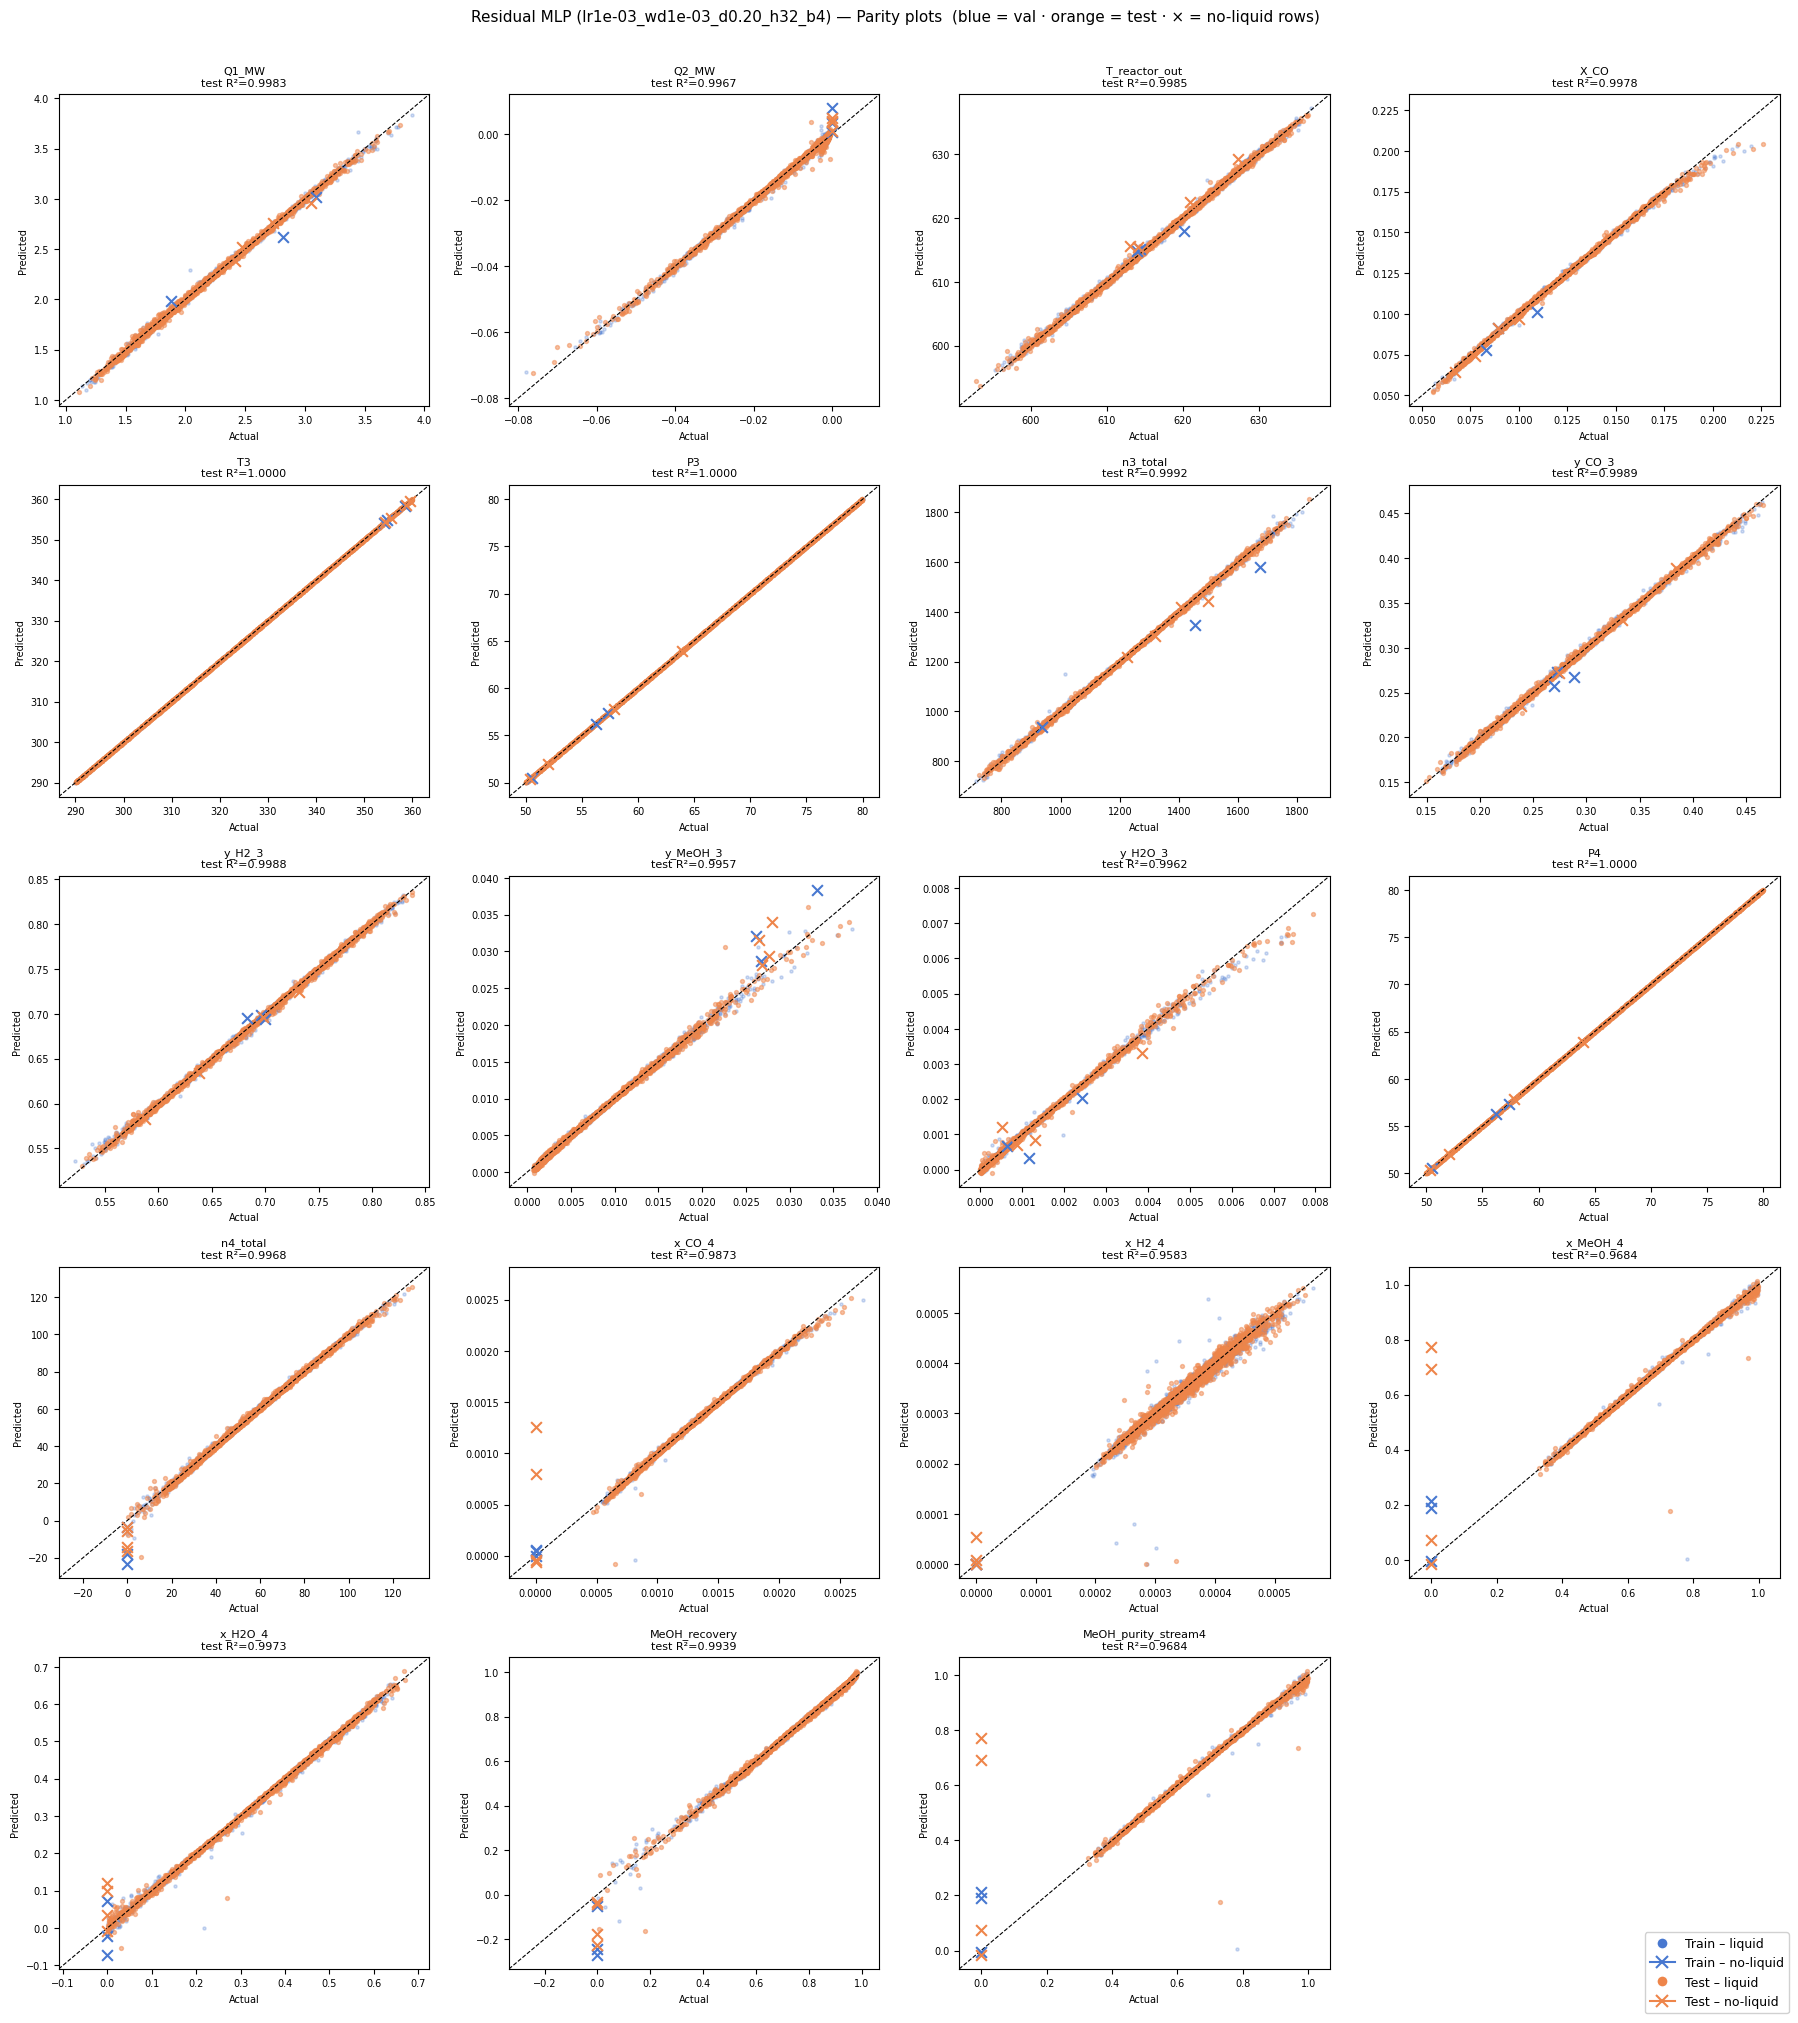

In [ ]:
val_pred_modeled = predict_raw(model, scaled.X_val_s, scaled.Y_transformer, device=device)
val_pred_full    = assemble_full_prediction(val_pred_modeled, data.X_train.iloc[scaled.val_idx])
y_val_true       = data.y_train.iloc[scaled.val_idx]
no_liquid_val_series = data.no_liquid_train.iloc[scaled.val_idx]

fig = parity_grid(
    y_train_true=y_val_true,
    y_train_pred=val_pred_full,
    y_test_true=data.y_test,
    y_test_pred=test_pred_full,
    no_liquid_train=no_liquid_val_series,
    no_liquid_test=data.no_liquid_test,
    columns=OUTPUT_COLS,
    title=f"Residual MLP ({winner_name}) Parity plots  (blue = val · orange = test · × = no-liquid rows)",
)
plt.show()

## 14. Save checkpoint

Save model weights, scalers, history, and winning hyperparameters to
`models/task3/residual.pt`. Task 4 (constrained optimization) reloads this
file with `torch.load(...)` and uses it as the differentiable surrogate.

In [17]:
# Pull hidden_mult from the model itself rather than re-deriving it.
# Block 0's lin1 maps hidden to d_hidden, so d_hidden / hidden is the multiplier.
_hm = model.blocks[0].lin1.out_features / model.blocks[0].lin1.in_features

save_checkpoint(
    "models/task3/residual.pt",
    model,
    scaled,
    history,
    extra={
        # --- Architecture identity (so loaders can rebuild the right class) ---
        "architecture":       "ResidualMLP_RTDL_pre_norm_bottleneck",
        "block_pattern":      "LayerNorm → Linear(d→d·mult) → GELU → Dropout1 → Linear(d·mult→d) → Dropout2 → +x",
        "reference":          "Gorishniy et al., NeurIPS 2021 — Revisiting Deep Learning Models for Tabular Data",

        # --- Constructor args needed to re-instantiate ResidualMLP(...) ---
        "in_dim":             len(INPUT_COLS),
        "out_dim":            len(MODEL_OUTPUT_COLS),
        "hidden":             winner_cfg["hidden"],
        "n_blocks":           winner_cfg["n_blocks"],
        "dropout":            winner_cfg["dropout"],
        "hidden_mult":        _hm,
        "activation":         "GELU",
        "norm":               "LayerNorm",
        "final_norm":         True,

        # --- Training metadata ---
        "winner":             winner_name,
        "lr":                 winner_cfg["lr"],
        "weight_decay":       winner_cfg["wd"],
        "es_patience":        winner_cfg["es_p"],
        "lr_patience":        5,
        "lr_min":             1e-8,
        "batch_size":         128,
        "random_state":       RANDOM_STATE,

        # --- Results & sweep audit trail ---
        "test_agg":           rmlp_test_agg,
        "sweep_results":      sweep_df.to_dict(orient="records"),
    },
)
print("Saved models/task3/residual.pt")
print(f"  architecture: ResidualMLP_RTDL_pre_norm_bottleneck")
print(f"  constructor : hidden={winner_cfg['hidden']}, n_blocks={winner_cfg['n_blocks']}, "
      f"dropout={winner_cfg['dropout']}, hidden_mult={_hm}")

Saved models/task3/residual.pt
  architecture: ResidualMLP_RTDL_pre_norm_bottleneck
  constructor : hidden=32, n_blocks=4, dropout=0.2, hidden_mult=2.0


## 15. Summary

Iteration-2 sweep winner: `lr1e-03_wd1e-03_d0.20_h32_b4`, 17,903 params,
best val loss 0.02715 at epoch 65, 125 epochs total.

Test R²=0.99213 (mean over 19 outputs including 3 deterministic outputs
clamped to R²=1.0). Clears both the XGBoost baseline (0.987) and the previous
post-norm residual run (0.98742). Key weak-output improvements over XGBoost:
`x_H2_4` 0.890 to 0.958, `x_MeOH_4` 0.962 to 0.968, `x_CO_4` 0.963 to 0.987.

Checkpoint saved to `models/task3/residual.pt` with full constructor args,
scalers, history, and sweep audit trail. Used as a component of the
constrained deep ensemble in `NN_Ensemble.ipynb` (Task 4 surrogate).